##  Setup


In [1]:
!pip -q install "albumentations==1.4.18"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.0/224.0 kB 18.1 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, random, json, math, time, zipfile, shutil, io
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

SEED = 42
def seed_all(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
seed_all()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
if device.type == 'cuda':
    print('gpu  :', torch.cuda.get_device_name(0))

/usr/local/lib/python3.12/dist-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


device: cuda
gpu  : Tesla T4


## Load dataset


In [4]:
DATA_DIR = Path('/content/drive/MyDrive/46_50_dataset/dataset')

if not DATA_DIR.exists():
    try:
        from google.colab import files
        print('Upload a zip whose root contains 46/, 47/, 48/, 49/, 50/ folders')
        uploaded = files.upload()
        name = next(iter(uploaded))
        with zipfile.ZipFile(io.BytesIO(uploaded[name])) as z:
            z.extractall('.')
        # if zip extracted as ./dataset/dataset/<cls>, flatten one level
        nested = DATA_DIR / 'dataset'
        if nested.exists():
            for p in nested.iterdir():
                shutil.move(str(p), DATA_DIR / p.name)
            nested.rmdir()
        # if zip dropped class folders directly at root, gather them
        if not DATA_DIR.exists():
            DATA_DIR.mkdir()
            for cls in ['46','47','48','49','50']:
                if Path(cls).exists():
                    shutil.move(cls, DATA_DIR / cls)
    except Exception as e:
        raise SystemExit(f'Provide the dataset (zip upload or mount Drive). {e}')

print('classes:', sorted(p.name for p in DATA_DIR.iterdir() if p.is_dir()))


classes: ['46', '47', '48', '49', '50']


In [5]:
CLASSES = sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir()])
class_to_idx = {c: i for i, c in enumerate(CLASSES)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

rows = []
for c in CLASSES:
    for f in sorted((DATA_DIR / c).glob('*.png')):
        rows.append({'path': str(f), 'label': class_to_idx[c], 'cls': c})
df = pd.DataFrame(rows)

print('classes :', class_to_idx)
print('total   :', len(df))
print(df.groupby('cls').size().to_string())


classes : {'46': 0, '47': 1, '48': 2, '49': 3, '50': 4}
total   : 239
cls
46    49
47    49
48    47
49    47
50    47


## EDA


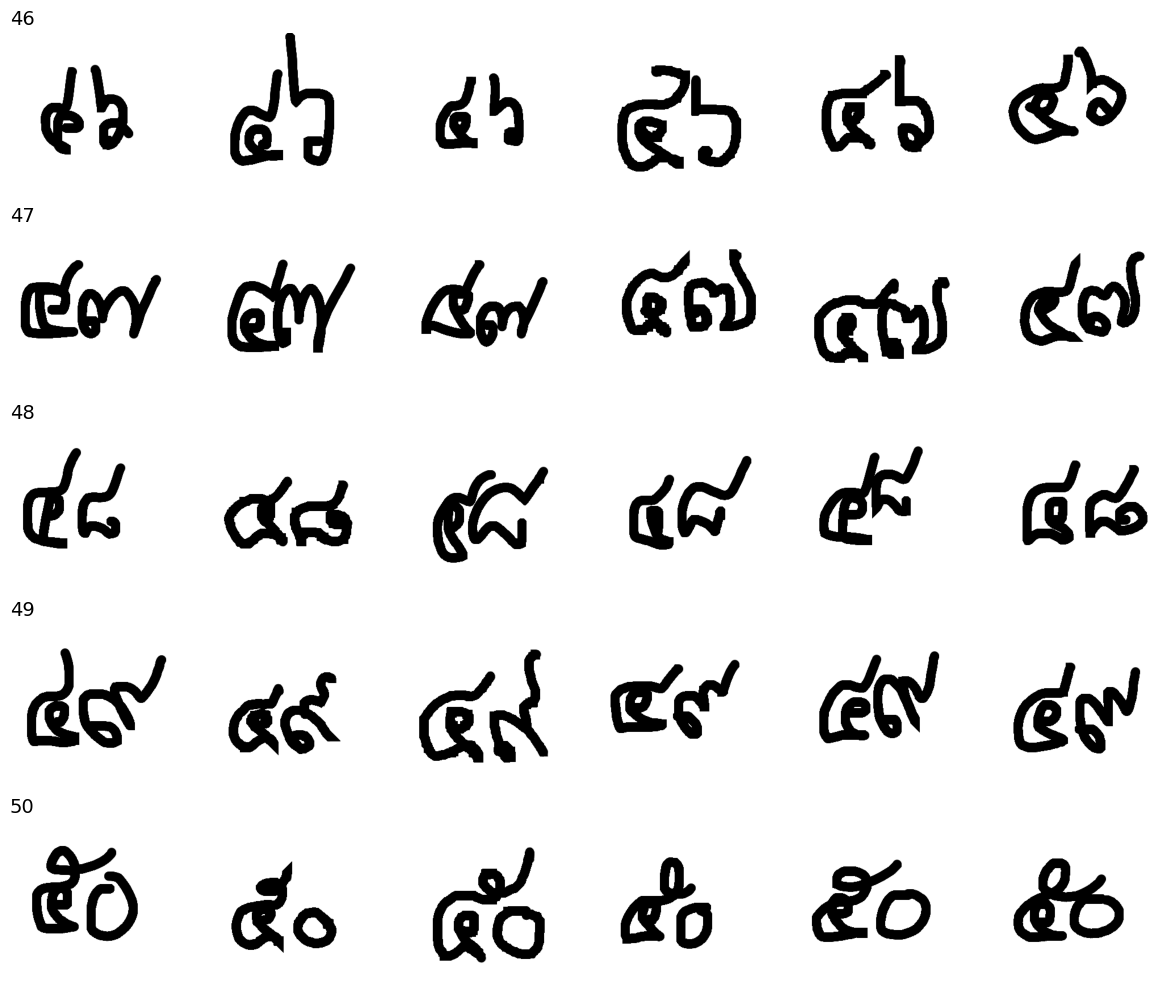

In [6]:
n_per = 6
fig, axes = plt.subplots(len(CLASSES), n_per, figsize=(2*n_per, 2*len(CLASSES)))
for i, c in enumerate(CLASSES):
    samp = df[df.cls == c].sample(min(n_per, (df.cls == c).sum()), random_state=0)
    for j, p in enumerate(samp.path):
        ax = axes[i, j] if len(CLASSES) > 1 else axes[j]
        ax.imshow(Image.open(p).convert('RGB')); ax.axis('off')
        if j == 0:
            ax.set_title(c, loc='left', fontsize=14, pad=6)
plt.tight_layout(); plt.show()


## Augmentation pipelines

In [7]:
IMG_SIZE = 96

train_tfms = A.Compose([
    A.LongestMaxSize(max_size=int(IMG_SIZE * 1.15)),
    A.PadIfNeeded(min_height=int(IMG_SIZE * 1.15),
                  min_width=int(IMG_SIZE * 1.15),
                  border_mode=0, value=255),
    A.Affine(scale=(0.85, 1.15), translate_percent=0.08,
             rotate=(-15, 15), shear=(-10, 10), cval=255, p=0.9),
    A.RandomResizedCrop(IMG_SIZE, IMG_SIZE,
                        scale=(0.8, 1.0), ratio=(0.9, 1.1), p=1.0),
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
        A.MotionBlur(blur_limit=5, p=1.0),
    ], p=0.3),
    A.OneOf([
        A.GaussNoise(var_limit=(5.0, 25.0), p=1.0),
        A.MultiplicativeNoise(multiplier=(0.9, 1.1), p=1.0),
    ], p=0.3),
    A.RandomBrightnessContrast(0.2, 0.2, p=0.5),
    A.CoarseDropout(max_holes=4, max_height=12, max_width=12,
                    fill_value=255, p=0.3),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2(),
])

val_tfms = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(IMG_SIZE, IMG_SIZE, border_mode=0, value=255),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2(),
])


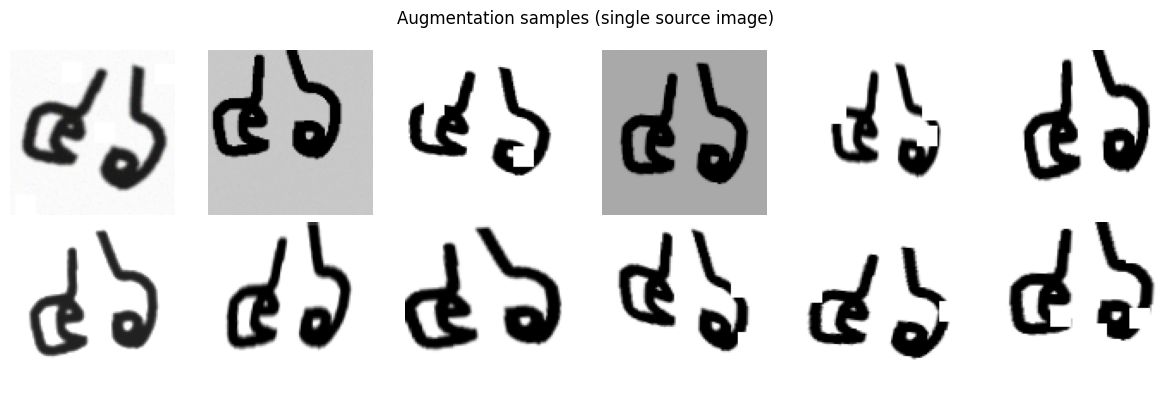

In [8]:
class ThaiDigitDataset(Dataset):
    def __init__(self, frame, tfms):
        self.paths = frame['path'].values
        self.labels = frame['label'].values
        self.tfms = tfms
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = np.array(Image.open(self.paths[i]).convert('RGB'))
        img = self.tfms(image=img)['image']
        return img, int(self.labels[i])

# preview augmentations on one image
ds_preview = ThaiDigitDataset(df.head(1), train_tfms)
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for k, ax in enumerate(axes.flat):
    x, _ = ds_preview[0]
    img = (x.permute(1,2,0).numpy() * 0.5 + 0.5).clip(0,1)
    ax.imshow(img); ax.axis('off')
plt.suptitle('Augmentation samples (single source image)'); plt.tight_layout(); plt.show()


## Model


In [9]:
class ConvBNAct(nn.Module):
    def __init__(self, c_in, c_out, k=3, s=1, p=1):
        super().__init__()
        self.conv = nn.Conv2d(c_in, c_out, k, s, p, bias=False)
        self.bn = nn.BatchNorm2d(c_out)
        self.act = nn.SiLU(inplace=True)
    def forward(self, x): return self.act(self.bn(self.conv(x)))

class ResBlock(nn.Module):
    def __init__(self, c, drop=0.0):
        super().__init__()
        self.b1 = ConvBNAct(c, c)
        self.b2 = nn.Sequential(
            nn.Conv2d(c, c, 3, 1, 1, bias=False),
            nn.BatchNorm2d(c),
        )
        self.drop = nn.Dropout2d(drop) if drop > 0 else nn.Identity()
        self.act = nn.SiLU(inplace=True)
    def forward(self, x):
        return self.act(self.drop(self.b2(self.b1(x))) + x)

class ThaiCNN(nn.Module):
    def __init__(self, n_classes=5, drop=0.3):
        super().__init__()
        self.stem   = ConvBNAct(3,   32, k=3, s=1)
        self.stage1 = nn.Sequential(ConvBNAct(32,  64,  s=2), ResBlock(64,  0.05))
        self.stage2 = nn.Sequential(ConvBNAct(64,  128, s=2), ResBlock(128, 0.10))
        self.stage3 = nn.Sequential(ConvBNAct(128, 256, s=2), ResBlock(256, 0.15))
        self.stage4 = nn.Sequential(ConvBNAct(256, 384, s=2), ResBlock(384, 0.20))
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(drop), nn.Linear(384, n_classes))
    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x); x = self.stage2(x); x = self.stage3(x); x = self.stage4(x)
        return self.head(self.gap(x))

_m = ThaiCNN(n_classes=len(CLASSES))
print(f'params: {sum(p.numel() for p in _m.parameters())/1e6:.2f}M')


params: 5.48M


##  Training utilities


In [10]:
def mixup_data(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def mixup_loss(crit, pred, ya, yb, lam):
    return lam * crit(pred, ya) + (1 - lam) * crit(pred, yb)

def run_epoch(model, loader, crit, opt=None, scaler=None, sched=None, mixup_alpha=0.0):
    train = opt is not None
    model.train(train)
    total = correct = 0; loss_sum = 0.0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        if train and mixup_alpha > 0:
            x, ya, yb, lam = mixup_data(x, y, mixup_alpha)
        with torch.set_grad_enabled(train):
            with autocast(enabled=scaler is not None):
                out = model(x)
                if train and mixup_alpha > 0:
                    loss = mixup_loss(crit, out, ya, yb, lam)
                else:
                    loss = crit(out, y)
            if train:
                opt.zero_grad(set_to_none=True)
                if scaler is not None:
                    scaler.scale(loss).backward()
                    scaler.unscale_(opt)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(opt); scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt.step()
                if sched is not None:
                    sched.step()
        loss_sum += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += x.size(0)
    return loss_sum / total, correct / total


## Single-model training

In [11]:
from sklearn.model_selection import train_test_split

EPOCHS       = 60
BATCH        = 32
LR           = 3e-3
WD           = 1e-4
PATIENCE     = 15
MIXUP        = 0.2
LABEL_SMOOTH = 0.1
VAL_SIZE     = 0.2

train_df, val_df = train_test_split(
    df,
    test_size=VAL_SIZE,
    stratify=df['label'],
    random_state=SEED,
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f'train={len(train_df)}  val={len(val_df)}')
print('train class counts:')
print(train_df.groupby('cls').size().to_string())
print('val class counts:')
print(val_df.groupby('cls').size().to_string())

train_ds = ThaiDigitDataset(train_df, train_tfms)
val_ds = ThaiDigitDataset(val_df, val_tfms)
train_ld = DataLoader(train_ds, BATCH, shuffle=True,  num_workers=2, pin_memory=True, drop_last=False)
val_ld   = DataLoader(val_ds,   BATCH, shuffle=False, num_workers=2, pin_memory=True)

model = ThaiCNN(n_classes=len(CLASSES)).to(device)
opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
crit  = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
sched = torch.optim.lr_scheduler.OneCycleLR(
    opt, max_lr=LR, steps_per_epoch=len(train_ld), epochs=EPOCHS, pct_start=0.1)
scaler = GradScaler() if device.type == 'cuda' else None

ckpt_dir = Path('checkpoints'); ckpt_dir.mkdir(exist_ok=True)
best_val_acc = 0.0
best_state = None
bad = 0

for ep in range(EPOCHS):
    tl, ta = run_epoch(model, train_ld, crit, opt, scaler, sched, mixup_alpha=MIXUP)
    vl, va = run_epoch(model, val_ld, crit)
    if va > best_val_acc:
        best_val_acc = va
        bad = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        bad += 1

    if ep % 5 == 0 or ep == EPOCHS - 1 or bad == 0:
        print(f'ep {ep:02d} | tl {tl:.3f} ta {ta:.3f} | vl {vl:.3f} va {va:.3f} | best {best_val_acc:.3f}')
    if bad >= PATIENCE:
        print(f'early stop @ epoch {ep}')
        break

model.load_state_dict(best_state)
torch.save(best_state, ckpt_dir / 'best_model.pt')

print('\n=========================================')
print(f'Best validation acc saved: {best_val_acc:.4f}')
print('Saved checkpoint: checkpoints/best_model.pt')
print('=========================================')


train=191  val=48
train class counts:
cls
46    39
47    39
48    38
49    38
50    37
val class counts:
cls
46    10
47    10
48     9
49     9
50    10


/tmp/ipykernel_400/520175059.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if device.type == 'cuda' else None
/tmp/ipykernel_400/3225604594.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=scaler is not None):


ep 00 | tl 1.649 ta 0.283 | vl 1.611 va 0.208 | best 0.208
ep 03 | tl 1.145 ta 0.330 | vl 16.399 va 0.333 | best 0.333
ep 04 | tl 1.182 ta 0.356 | vl 16.155 va 0.396 | best 0.396
ep 05 | tl 1.064 ta 0.393 | vl 4.403 va 0.312 | best 0.396
ep 08 | tl 0.885 ta 0.518 | vl 1.354 va 0.542 | best 0.542
ep 10 | tl 0.809 ta 0.361 | vl 1.760 va 0.708 | best 0.708
ep 12 | tl 0.847 ta 0.429 | vl 0.851 va 0.833 | best 0.833
ep 15 | tl 1.048 ta 0.529 | vl 0.857 va 0.771 | best 0.833
ep 19 | tl 0.643 ta 0.618 | vl 0.674 va 0.854 | best 0.854
ep 20 | tl 0.839 ta 0.649 | vl 0.520 va 0.979 | best 0.979
ep 22 | tl 0.782 ta 0.586 | vl 0.493 va 1.000 | best 1.000
ep 25 | tl 0.750 ta 0.534 | vl 0.521 va 1.000 | best 1.000
ep 30 | tl 0.790 ta 0.503 | vl 0.675 va 0.917 | best 1.000
ep 35 | tl 0.551 ta 0.466 | vl 0.461 va 0.979 | best 1.000
early stop @ epoch 37

Best validation acc saved: 1.0000
Saved checkpoint: checkpoints/best_model.pt


## 8. Validation evaluation

Validation accuracy: 1.0000

              precision    recall  f1-score   support

          46     1.0000    1.0000    1.0000        10
          47     1.0000    1.0000    1.0000        10
          48     1.0000    1.0000    1.0000         9
          49     1.0000    1.0000    1.0000         9
          50     1.0000    1.0000    1.0000        10

    accuracy                         1.0000        48
   macro avg     1.0000    1.0000    1.0000        48
weighted avg     1.0000    1.0000    1.0000        48



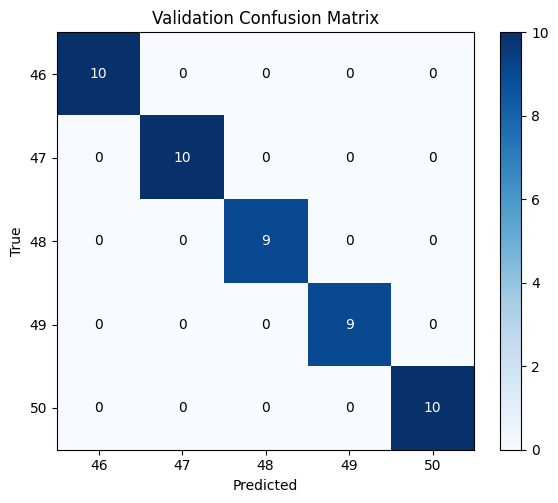

In [12]:
model.eval()
val_probs = []
val_true = []

with torch.no_grad():
    for x, y in val_ld:
        x = x.to(device)
        p = F.softmax(model(x), dim=1).cpu().numpy()
        val_probs.append(p)
        val_true.append(y.numpy())

val_probs = np.concatenate(val_probs, axis=0)
val_true = np.concatenate(val_true, axis=0)
val_pred = val_probs.argmax(1)

print(f'Validation accuracy: {accuracy_score(val_true, val_pred):.4f}\n')
print(classification_report(val_true, val_pred, target_names=CLASSES, digits=4))

cm = confusion_matrix(val_true, val_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASSES))); ax.set_yticks(range(len(CLASSES)))
ax.set_xticklabels(CLASSES); ax.set_yticklabels(CLASSES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('Validation Confusion Matrix')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im); plt.tight_layout(); plt.show()


## 9. Single-model inference

In [13]:
@torch.no_grad()
def predict_image(image_path):
    m = ThaiCNN(n_classes=len(CLASSES)).to(device)
    m.load_state_dict(torch.load(ckpt_dir / 'best_model.pt', map_location=device))
    m.eval()

    img = np.array(Image.open(image_path).convert('RGB'))
    x = val_tfms(image=img)['image'].unsqueeze(0).to(device)
    p = F.softmax(m(x), dim=1)[0].cpu().numpy()
    return CLASSES[int(p.argmax())], {c: float(p[i]) for i, c in enumerate(CLASSES)}

# demo on a few validation samples
for _, row in val_df.sample(min(5, len(val_df)), random_state=1).iterrows():
    pred, prob = predict_image(row['path'])
    mark = 'OK ' if pred == row['cls'] else 'XX '
    print(f'{mark} truth={row["cls"]}  pred={pred}  probs={ {k: round(v,3) for k,v in prob.items()} }')


OK  truth=48  pred=48  probs={'46': 0.034, '47': 0.011, '48': 0.91, '49': 0.011, '50': 0.034}
OK  truth=48  pred=48  probs={'46': 0.021, '47': 0.011, '48': 0.911, '49': 0.03, '50': 0.027}
OK  truth=50  pred=50  probs={'46': 0.007, '47': 0.005, '48': 0.005, '49': 0.006, '50': 0.977}
OK  truth=50  pred=50  probs={'46': 0.005, '47': 0.005, '48': 0.004, '49': 0.004, '50': 0.982}
OK  truth=47  pred=47  probs={'46': 0.121, '47': 0.672, '48': 0.106, '49': 0.072, '50': 0.03}


## 10. Save artifacts

In [14]:
mapping = {
    'classes'      : CLASSES,
    'class_to_idx' : class_to_idx,
    'idx_to_class' : {int(k): v for k, v in idx_to_class.items()},
    'img_size'     : IMG_SIZE,
    'normalize'    : {'mean': [0.5, 0.5, 0.5], 'std': [0.5, 0.5, 0.5]},
    'best_val_acc' : best_val_acc,
}
with open(ckpt_dir / 'class_mapping.json', 'w') as f:
    json.dump(mapping, f, indent=2)

print('saved artifacts:')
for p in sorted(ckpt_dir.iterdir()):
    print(' ', p, f'{p.stat().st_size/1e6:.2f} MB')

try:
    from google.colab import files as gfiles
    shutil.make_archive('thai_handwriting_model', 'zip', ckpt_dir)
    gfiles.download('thai_handwriting_model.zip')
except Exception:
    pass

saved artifacts:
  checkpoints/best_model.pt 21.97 MB
  checkpoints/class_mapping.json 0.00 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>